In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


# GMM 聚类

BIC 作为评价标准

### 读入数据，预处理

In [2]:
# ----------------------------------------------------
# 1. 读取融合后的特征空间数据
# ----------------------------------------------------
FEATURE_CSV = "Multi-Feature_result/fused_features_for_clustering-1Y.csv"
OUTPUT_DIR = "Multi-Feature_result/Kmeans_results-1Y"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df_feat = pd.read_csv(FEATURE_CSV, index_col=0)  # index 是节点名
X = df_feat.values
node_names = df_feat.index.tolist()

print("Feature matrix shape:", X.shape)

# ----------------------------------------------------
# 2. （可选但强烈建议）整体再标准化一次
#    防止模块权重差异残留
# ----------------------------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

Feature matrix shape: (68, 45)


尝试PCA降维

达到 95% 累计解释方差所需的最小维度: 11


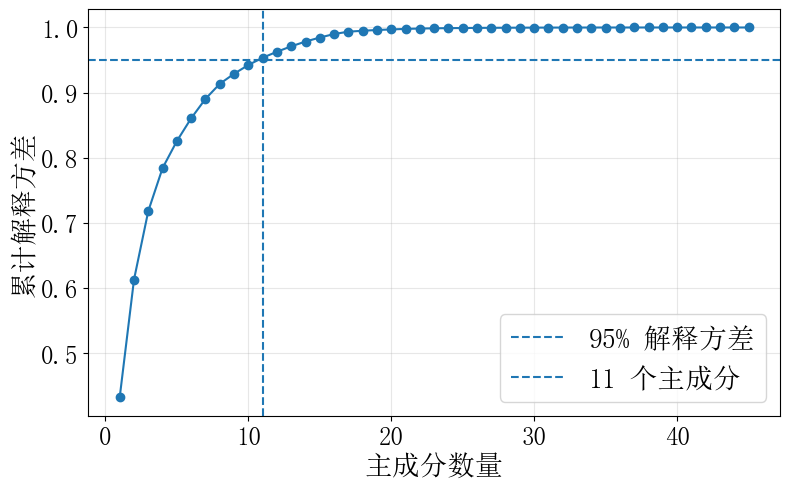

In [3]:
# ----------------------------------------------------
# 3. PCA：解释方差分析（用于决定降维维数）
# ----------------------------------------------------
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ========== 字体与字号设置 ==========
FONT_SIZE = 20                     # 基础字号，可自由调整
plt.rcParams['font.family'] = 'SimSun'        # 全局使用宋体
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号
# ===================================

# 先做一次不限制维度的 PCA，用于查看解释方差
# 注意：这里假设 X_std 已经完成标准化
pca_full = PCA()
pca_full.fit(X_std)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# 找到达到 95% 解释方差所需的最小维度
dim_95 = np.searchsorted(cumulative_variance, 0.95) + 1

print(f"达到 95% 累计解释方差所需的最小维度: {dim_95}")

# ----------------------------------------------------
# 4. 绘制累计解释方差曲线
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.axhline(0.95, linestyle='--', label='95% 解释方差')
plt.axvline(dim_95, linestyle='--', label=f'{dim_95} 个主成分')

plt.xlabel("主成分数量", fontsize=FONT_SIZE)
plt.ylabel("累计解释方差", fontsize=FONT_SIZE)
plt.legend(fontsize=FONT_SIZE)
plt.grid(alpha=0.3)
plt.xticks(fontsize=FONT_SIZE-2)
plt.yticks(fontsize=FONT_SIZE-2)
plt.tight_layout()
plt.show()

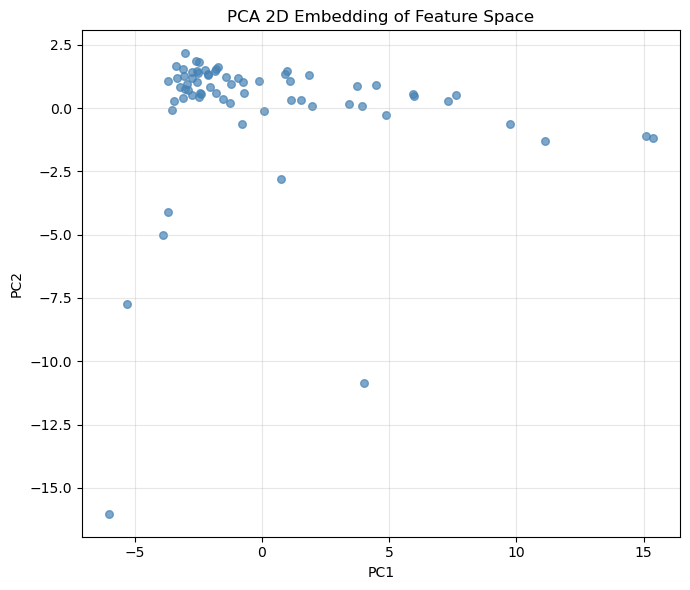

In [4]:
# 观察二维的数据节点构成 肉眼观察类别

# ----------------------------------------------------
# 5.1 PCA 2D embedding 可视化（用于观察数据结构）
# ----------------------------------------------------
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_std)

plt.figure(figsize=(7,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    s=30,
    alpha=0.7,
    color="steelblue"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Embedding of Feature Space")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# ----------------------------------------------------
# 5. PCA 降维
# ----------------------------------------------------
TARGET_DIM = 11   # 你假设的目标维度

pca = PCA(n_components=TARGET_DIM)
X_pca = pca.fit_transform(X_std)

print("PCA-reduced feature shape:", X_pca.shape)

PCA-reduced feature shape: (68, 11)


### 试探聚类


===== KMeans 聚类 K = 2 =====


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


轮廓系数: 0.4927
惯性 (SSE): 1949.60
标签文件已保存至: Multi-Feature_result/Kmeans_results-1Y\kmeans_labels_K2.csv

===== KMeans 聚类 K = 3 =====


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


轮廓系数: 0.4901
惯性 (SSE): 1587.33
标签文件已保存至: Multi-Feature_result/Kmeans_results-1Y\kmeans_labels_K3.csv

===== KMeans 聚类 K = 4 =====


...

轮廓系数: 0.3777
惯性 (SSE): 958.04
标签文件已保存至: Multi-Feature_result/Kmeans_results-1Y\kmeans_labels_K5.csv

===== KMeans 聚类 K = 6 =====


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


轮廓系数: 0.3680
惯性 (SSE): 817.98
标签文件已保存至: Multi-Feature_result/Kmeans_results-1Y\kmeans_labels_K6.csv

===== KMeans 聚类 K = 7 =====


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


轮廓系数: 0.3715
惯性 (SSE): 680.28
标签文件已保存至: Multi-Feature_result/Kmeans_results-1Y\kmeans_labels_K7.csv


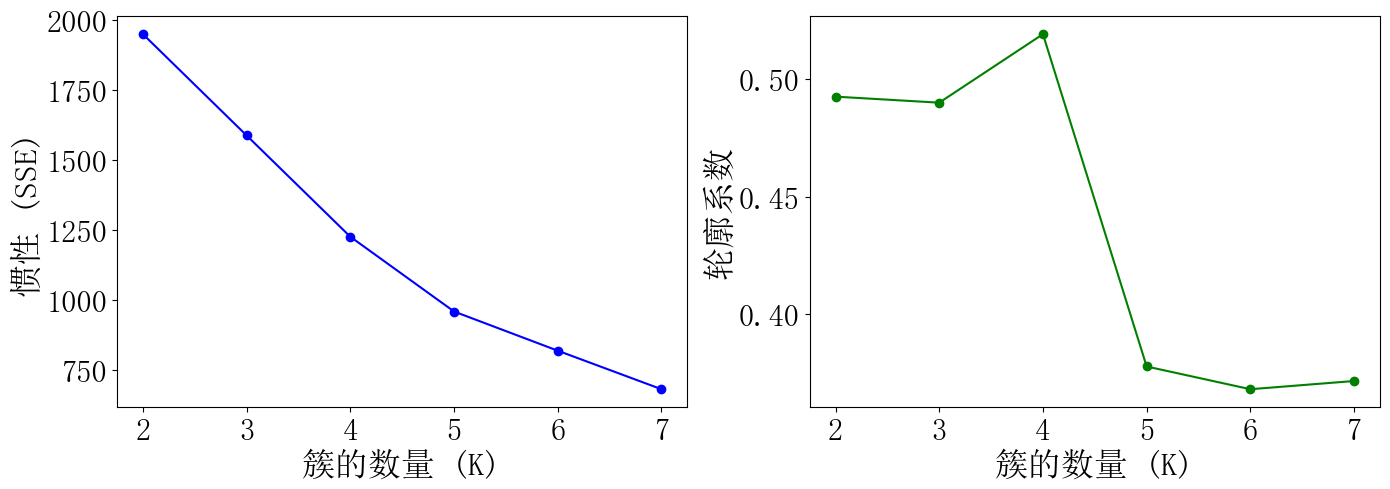


最佳轮廓系数: K = 4, 得分 = 0.5193


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ========== 字体与字号设置 ==========
plt.rcParams.update({'font.family': 'SimSun'})   # 中英文数字全部使用宋体
plt.rcParams['axes.unicode_minus'] = False       # 正确显示负号
FONT_SIZE = 24                                   # 可调节的基础字号
# ===================================

# ----------------------------------------------------
# KMeans 聚类：K = 2 ~ 7（可根据需要调整范围）
# ----------------------------------------------------
inertia_scores = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:

    print(f"\n===== KMeans 聚类 K = {k} =====")

    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = kmeans.fit_predict(X_pca)

    # -------- 轮廓系数 --------
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"轮廓系数: {score:.4f}")

    # -------- 惯性 (SSE) --------
    inertia = kmeans.inertia_
    inertia_scores.append(inertia)
    print(f"惯性 (SSE): {inertia:.2f}")

    # -------- 保存标签文件 --------
    label_df = pd.DataFrame({"label": labels}, index=node_names)
    out_csv = os.path.join(OUTPUT_DIR, f"kmeans_labels_K{k}.csv")
    label_df.to_csv(out_csv)
    print(f"标签文件已保存至: {out_csv}")

# -------- 绘制肘部曲线和轮廓系数 --------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 肘部曲线
ax1.plot(list(k_range), inertia_scores, marker="o", color='blue')
ax1.set_xlabel("簇的数量 (K)", fontsize=FONT_SIZE)
ax1.set_ylabel("惯性 (SSE)", fontsize=FONT_SIZE)
ax1.tick_params(labelsize=FONT_SIZE - 2)

# 轮廓系数图
ax2.plot(list(k_range), silhouette_scores, marker="o", color='green')
ax2.set_xlabel("簇的数量 (K)", fontsize=FONT_SIZE)
ax2.set_ylabel("轮廓系数", fontsize=FONT_SIZE)
ax2.tick_params(labelsize=FONT_SIZE - 2)

plt.tight_layout()
plt.show()

# 打印最佳轮廓系数对应的 K
best_k = list(k_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
print(f"\n最佳轮廓系数: K = {best_k}, 得分 = {best_score:.4f}")

### 聚类后检验有无物理意义

可尝试的聚类数目：5, 6

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
import math
from matplotlib.gridspec import GridSpec   # 新增


def plot_cluster_pie_by_space_usage(K):

    """
    根据 KMeans clustering label 绘制 cluster 组成饼图
    并绘制每个 cluster 的负荷时间序列
    """

    # =========================
    # 0. 全局绘图风格
    # =========================
    mpl.rcParams["font.family"] = "Times New Roman"
    mpl.rcParams["font.size"] = 12

    title_fontsize = 29
    legend_fontsize = 25
    legend_title_fontsize = 28

    # =========================
    # 1. 读取聚类 label
    # =========================
    csv_path = os.path.join(
        "Multi-Feature_result",
        "Kmeans_results-1Y",
        f"kmeans_labels_K{K}.csv"
    )

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"File not found: {csv_path}")

    df_cluster = pd.read_csv(csv_path, index_col=0)

    # 节点名
    df_cluster["location"] = df_cluster.index

    # 提取 building type
    df_cluster["second_word"] = df_cluster["location"].str.split("_").str[1]

    # =========================
    # 2. 颜色映射
    # =========================
    word_colors = {
        "education": "#D62728",
        "office": "#2CA02C",
        "lodging": "#1F77B4",
        "health": "#9467BD",
        "science": "#7F7F7F",
        "public": "#F1C40F",
        "assembly": "#FF7F0E",
    }

    # =========================
    # 3. 统计每个 cluster 的 building type
    # =========================
    labels = list(range(K))
    stats = {}

    print("\n========== Cluster Statistics ==========\n")

    for lb in labels:

        words = df_cluster.loc[df_cluster["label"] == lb, "second_word"]

        counter = Counter(words)

        stats[lb] = counter

        print(f"Cluster {lb}")
        print(f"Total samples: {len(words)}")

        for k, v in counter.items():
            print(f"  {k}: {v}")

        print("-" * 40)

    # =========================
    # 4. 所有 building type
    # =========================
    all_words = sorted(df_cluster["second_word"].unique())

    colors = [word_colors[w] for w in all_words]

    # =========================
    # 5. 自动布局 —— 使用 GridSpec 让图例与饼图间距一致
    # =========================
    n_cols = math.ceil(math.sqrt(K))
    n_rows = math.ceil(K / n_cols)

    # 右侧多出一列专门放图例
    fig = plt.figure(figsize=(6 * (n_cols + 1), 5 * n_rows))
    gs = GridSpec(n_rows, n_cols + 1, figure=fig,
                  wspace=0.35, hspace=0.4)   # wspace 同时控制饼图之间、及饼图到图例的距离

    axes = []
    for i in range(K):
        row = i // n_cols
        col = i % n_cols
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)

    # 图例所在的轴，占满最后一列
    ax_legend = fig.add_subplot(gs[:, n_cols])
    ax_legend.axis("off")   # 只显示图例，不显示轴框

    # =========================
    # 6. 绘制 pie chart
    # =========================
    legend_handles = None

    for lb, ax in zip(labels, axes):

        counter = stats[lb]

        sizes = [counter.get(w, 0) for w in all_words]

        wedges, _ = ax.pie(
            sizes,
            colors=colors,
            startangle=90
        )

        ax.set_title(f"Cluster {lb}", fontsize=title_fontsize)

        ax.axis("equal")

        if legend_handles is None:
            legend_handles = wedges   # 保存一份用于图例

    # =========================
    # 7. 将图例放在右侧专用轴中 —— 与饼图距离等于饼图间距
    # =========================
    ax_legend.legend(
        legend_handles,
        all_words,
        loc="center",
        fontsize=legend_fontsize,
        title="Primary Space Usage",
        title_fontsize=legend_title_fontsize
    )

    # 使用 tight_layout 自动调整边距
    plt.tight_layout()

    plt.show()

    # =========================
    # 8. 读取负荷时间序列
    # =========================
    ts_path = os.path.join(
        "..",
        "..",
        "electricityLondon",
        "electricityLondon_24hfilled.csv"
    )

    if not os.path.exists(ts_path):
        raise FileNotFoundError(f"File not found: {ts_path}")

    df_ts = pd.read_csv(ts_path)

    if "timestamp" in df_ts.columns:
        df_ts = df_ts.drop(columns=["timestamp"])

    node_names = df_ts.columns.tolist()

    series_length = len(df_ts)

    X = df_ts.values.T

    # =========================
    # 9. cluster time series
    # =========================
    output_dir = os.path.join(
        "Multi-Feature_result",
        "Kmeans_results-1Y",
        f"K{K}"
    )

    os.makedirs(output_dir, exist_ok=True)

    labels_array = df_cluster.reindex(node_names)["label"].values

    print("\n========== Plot Cluster Time Series ==========\n")

    for cid in range(K):

        member_idx = [i for i, lb in enumerate(labels_array) if lb == cid]

        if len(member_idx) == 0:
            continue

        fig, ax = plt.subplots(figsize=(12, 4))

        for i in member_idx:

            ax.plot(
                range(series_length),
                X[i],
                linewidth=0.6,
                alpha=0.7,
                zorder=1,
                color="0.6",
                solid_capstyle="round"
            )

        center_series = X[member_idx].mean(axis=0)

        ax.plot(
            range(series_length),
            center_series,
            linewidth=1.5,
            color="red",
            zorder=2,
            label="Cluster center (mean)"
        )

        ax.set_xlabel("Time step")
        ax.set_ylabel("Electricity load")

        ax.set_title(
            f"Cluster {cid} members with center"
        )

        tick_step = 500

        ticks = list(range(0, series_length, tick_step))

        if (series_length - 1) not in ticks:
            ticks.append(series_length - 1)

        ax.set_xticks(ticks)

        ax.set_xticklabels([str(t) for t in ticks])

        ax.grid(False)

        plt.tight_layout()

        out_png = os.path.join(
            output_dir,
            f"cluster_{cid}_members_with_center.png"
        )

        fig.savefig(out_png, dpi=300)

        plt.close(fig)

        print(f"Cluster {cid} time series saved: {out_png}")

    print("\nAll cluster time series plots saved to:", output_dir)


========== Cluster Statistics ==========

Cluster 0
Total samples: 4
  education: 2
  office: 1
  health: 1
----------------------------------------
Cluster 1
Total samples: 55
  public: 2
  lodging: 11
  education: 17
  office: 23
  assembly: 1
  health: 1
----------------------------------------
Cluster 2
Total samples: 8
  education: 3
  office: 2
  health: 3
----------------------------------------
Cluster 3
Total samples: 1
  science: 1
----------------------------------------


C:\Users\DELL\AppData\Local\Temp\ipykernel_32172\1946686068.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


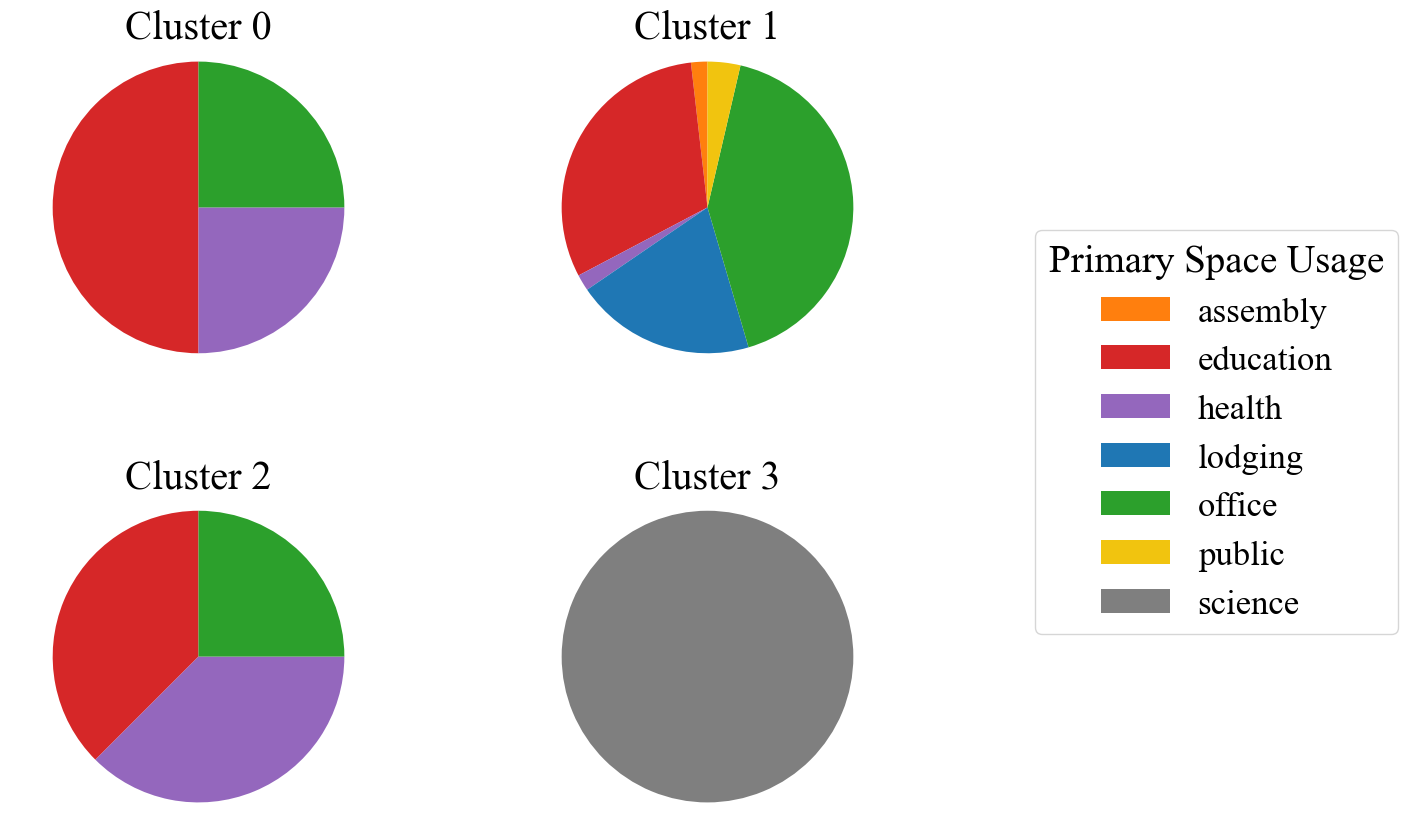


========== Plot Cluster Time Series ==========

Cluster 0 time series saved: Multi-Feature_result\Kmeans_results-1Y\K4\cluster_0_members_with_center.png
Cluster 1 time series saved: Multi-Feature_result\Kmeans_results-1Y\K4\cluster_1_members_with_center.png
Cluster 2 time series saved: Multi-Feature_result\Kmeans_results-1Y\K4\cluster_2_members_with_center.png
Cluster 3 time series saved: Multi-Feature_result\Kmeans_results-1Y\K4\cluster_3_members_with_center.png

All cluster time series plots saved to: Multi-Feature_result\Kmeans_results-1Y\K4


In [10]:
plot_cluster_pie_by_space_usage(4)


========== Cluster Statistics ==========

Cluster 0
Total samples: 41
  public: 2
  lodging: 11
  education: 8
  office: 18
  assembly: 1
  health: 1
----------------------------------------
Cluster 1
Total samples: 1
  science: 1
----------------------------------------
Cluster 2
Total samples: 6
  education: 3
  office: 1
  health: 2
----------------------------------------
Cluster 3
Total samples: 4
  education: 2
  office: 1
  health: 1
----------------------------------------
Cluster 4
Total samples: 16
  education: 9
  office: 6
  health: 1
----------------------------------------


C:\Users\DELL\AppData\Local\Temp\ipykernel_32172\1946686068.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


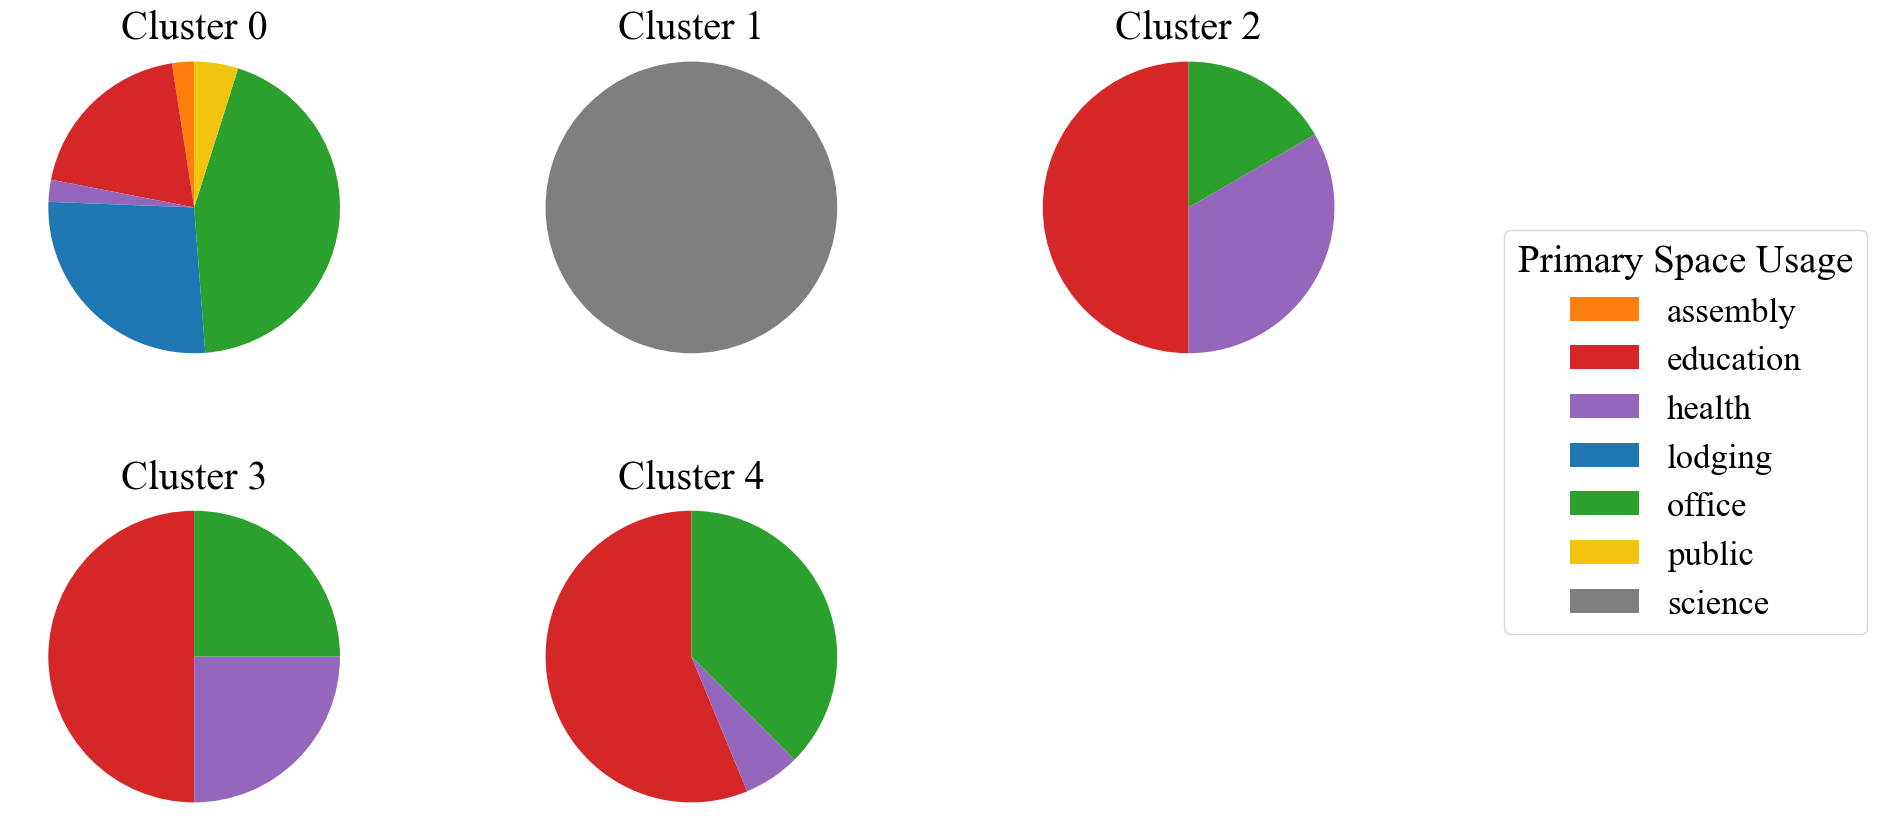


========== Plot Cluster Time Series ==========

Cluster 0 time series saved: Multi-Feature_result\Kmeans_results-1Y\K5\cluster_0_members_with_center.png
Cluster 1 time series saved: Multi-Feature_result\Kmeans_results-1Y\K5\cluster_1_members_with_center.png
Cluster 2 time series saved: Multi-Feature_result\Kmeans_results-1Y\K5\cluster_2_members_with_center.png
Cluster 3 time series saved: Multi-Feature_result\Kmeans_results-1Y\K5\cluster_3_members_with_center.png
Cluster 4 time series saved: Multi-Feature_result\Kmeans_results-1Y\K5\cluster_4_members_with_center.png

All cluster time series plots saved to: Multi-Feature_result\Kmeans_results-1Y\K5


In [11]:
plot_cluster_pie_by_space_usage(5)

In [7]:
# ----------------------------------------------------
# 提取K=4聚类标签列表
# ----------------------------------------------------
import pandas as pd

OUTPUT_DIR = "Multi-Feature_result/Kmeans_results-1Y"
# 读取K=4的聚类结果（使用相对路径）
k4_csv_path = os.path.join(
    OUTPUT_DIR,
    "kmeans_labels_K4.csv"
)

df_k4 = pd.read_csv(k4_csv_path, index_col=0)

# 按CSV文件中的顺序提取标签（保持原始顺序）
cluster_assignments_k4 = df_k4["label"].tolist()

print(f"K=4聚类标签列表（共{len(cluster_assignments_k4)}个节点）：")
print(cluster_assignments_k4)

# 验证节点顺序与CSV一致
print(f"\n节点顺序验证：")
for i, (node, label) in enumerate(zip(df_k4.index[:10], cluster_assignments_k4[:10])):
    print(f"  {node}: {label}")
print("  ...")

K=4聚类标签列表（共68个节点）：
[1, 1, 1, 1, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 2, 1, 2, 1, 2, 3]

节点顺序验证：
  Robin_public_Carolina: 1
  Robin_lodging_Dorthy: 1
  Robin_education_Zenia: 1
  Robin_office_Dina: 1
  Robin_education_Derick: 2
  Robin_education_Della: 0
  Robin_education_Leslie: 2
  Robin_office_Sammie: 1
  Robin_education_Mercedes: 1
  Robin_education_Julius: 2
  ...
